✅ 2D Asset kaydedildi: ../../../assets\48_fourier_2d.png


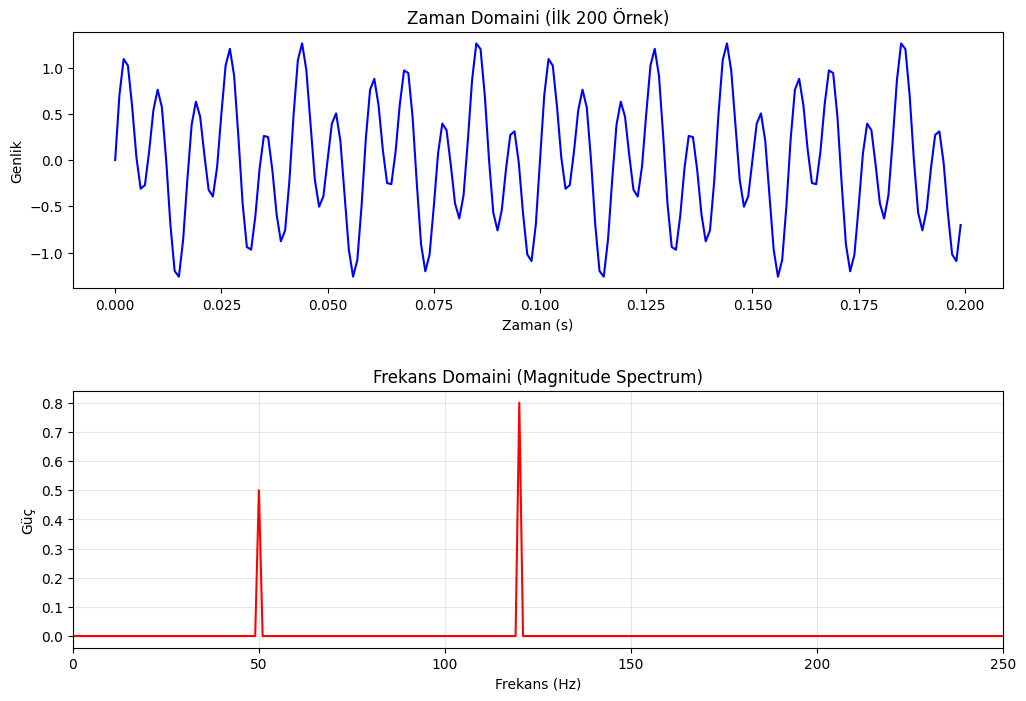

✅ 3D Asset kaydedildi: ../../../assets\48_fourier_3d.png


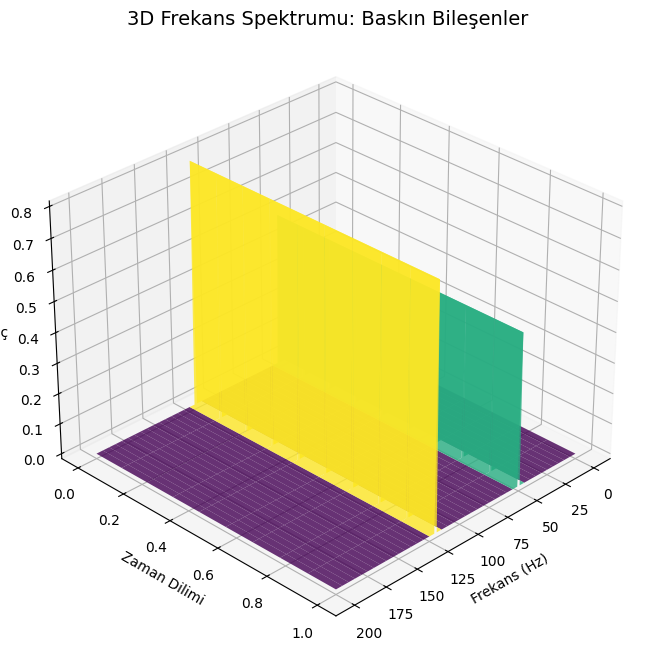

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import os

def run_fourier_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Sinyal Oluşturma (Karmaşık bir dalga)
    fs = 1000  # Örnekleme frekansı
    T = 1.0    # Süre (saniye)
    t = np.linspace(0, T, fs, endpoint=False)
    
    # İki farklı frekansın birleşimi: 50Hz ve 120Hz + Gürültü
    sig = 0.5 * np.sin(2 * np.pi * 50 * t) + 0.8 * np.sin(2 * np.pi * 120 * t)
    
    # 2. FFT Hesaplama
    n = len(t)
    yf = fft(sig)
    xf = fftfreq(n, 1/fs)[:n//2]
    magnitude = 2.0/n * np.abs(yf[0:n//2])

    # --- 📸 ASSET 1: TIME DOMAIN VS FREQUENCY DOMAIN (48_fourier_2d.png) ---
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig1.subplots_adjust(hspace=0.4)
    
    ax1.plot(t[:200], sig[:200], 'b')
    ax1.set_title("Zaman Domaini (İlk 200 Örnek)")
    ax1.set_xlabel("Zaman (s)"); ax1.set_ylabel("Genlik")
    
    ax2.plot(xf, magnitude, 'r')
    ax2.set_title("Frekans Domaini (Magnitude Spectrum)")
    ax2.set_xlabel("Frekans (Hz)"); ax2.set_ylabel("Güç")
    ax2.set_xlim(0, 250) # İlgi alanımız
    ax2.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '48_fourier_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\48_fourier_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D SPECTRAL PEAKS (48_fourier_3d.png) ---
    fig2 = plt.figure(figsize=(10, 8))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # 3D'de frekansları net görmek için bir 'Waterfall' benzeri yapı kuralım
    freq_grid = xf[(xf >= 0) & (xf <= 200)]
    mag_grid = magnitude[:len(freq_grid)]
    
    # Zaman ekseninde kopyalayarak bir yüzey oluşturalım
    time_steps = np.linspace(0, 1, 10)
    F, T_mesh = np.meshgrid(freq_grid, time_steps)
    M = np.tile(mag_grid, (len(time_steps), 1))

    surf = ax3d.plot_surface(F, T_mesh, M, cmap='viridis', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Frekans Spektrumu: Baskın Bileşenler", fontsize=14)
    ax3d.set_xlabel('Frekans (Hz)'); ax3d.set_ylabel('Zaman Dilimi'); ax3d.set_zlabel('Güç')
    ax3d.view_init(elev=30, azim=45)

    plt.savefig(os.path.join(asset_path, '48_fourier_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\48_fourier_3d.png")
    plt.show()

if __name__ == "__main__":
    run_fourier_master()
